In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

In [2]:
log = []

def record(df, comment=""):
    nrows = df.shape[0]
    ncompounds = df["Molecule ChEMBL ID"].nunique()
    log.append({"N Rows": nrows, "N compounds": ncompounds, "Step": comment})
    print(f"{nrows:,} rows | {comment}")

In [3]:
import pandas as pd

df = pd.read_csv(DATA_RAW / "CHEMBL203_activities.zip", sep=";")
record(df, "Raw table")
df.head()

58,847 rows | Raw table


C:\Users\lauren\AppData\Local\Temp\ipykernel_14444\169340208.py:3: DtypeWarning: Columns (27: Assay Tissue ChEMBL ID, 28: Assay Tissue Name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_RAW / "CHEMBL203_activities.zip", sep=";")


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL3808884,NaN,NaN,562.55,2.0,6.04,6z,COC(=O)c1cc2cc(NCc3cc(NC(=O)c4cc(-n5cnc(C)c5)c...,IC50,'=',...,CHEMBL3808348,1,Scientific Literature,J Med Chem,2016.0,NaN,NaN,NaN,NaN,112.0
1,CHEMBL1682353,NaN,NaN,289.34,0.0,3.18,4k,Cc1cccc(Cn2cc(-c3ccc4[nH]ncc4c3)nn2)c1,Ki,NaN,...,CHEMBL1681644,1,Scientific Literature,Bioorg Med Chem Lett,2011.0,NaN,NaN,NaN,NaN,NaN
2,CHEMBL1682354,NaN,NaN,344.20,0.0,4.18,4l,Clc1cccc(Cn2cc(-c3ccc4[nH]ncc4c3)nn2)c1Cl,Ki,NaN,...,CHEMBL1681644,1,Scientific Literature,Bioorg Med Chem Lett,2011.0,NaN,NaN,NaN,NaN,NaN
3,CHEMBL138940,NaN,NaN,513.96,1.0,2.89,31,O=C(/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn...,IC50,'=',...,CHEMBL1134843,1,Scientific Literature,J Med Chem,2001.0,CHEMBL3307523,NaN,NaN,NaN,14.0
4,CHEMBL5886334,NaN,NaN,461.55,0.0,0.96,BDBM309682,CN(C)C(=O)N[C@@H]1CCCN(c2cnc(C(N)=O)c(Nc3ccc(S...,kon,'=',...,CHEMBL5725990,37,BindingDB Patent Bioactivity Data,NaN,2017.0,NaN,NaN,NaN,NaN,NaN


In [4]:
df.columns

Index(['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase',
       'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key',
       'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value',
       'Standard Units', 'pChEMBL Value', 'Data Validity Comment', 'Comment',
       'Uo Units', 'Ligand Efficiency BEI', 'Ligand Efficiency LE',
       'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Potential Duplicate',
       'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID',
       'BAO Label', 'Assay Organism', 'Assay Tissue ChEMBL ID',
       'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction',
       'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type',
       'Document ChEMBL ID', 'Source ID', 'Source Description',
       'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties',
       'Action Type', 'Standard Text Value', 'V

In [5]:
df = df[["Standard Type", "Standard Value", "Standard Units", "Standard Relation", "pChEMBL Value", "Assay ChEMBL ID", "Assay Description", "Assay Type", "Target Organism", "Data Validity Comment", "Smiles", "Molecule ChEMBL ID"]]
df.head()

,Standard Type,Standard Value,Standard Units,Standard Relation,pChEMBL Value,Assay ChEMBL ID,Assay Description,Assay Type,Target Organism,Data Validity Comment,Smiles,Molecule ChEMBL ID
0,IC50,112.0,nM,'=',6.95,CHEMBL3810820,Inhibition of GST-tagged human recombinant EGF...,B,Homo sapiens,NaN,COC(=O)c1cc2cc(NCc3cc(NC(=O)c4cc(-n5cnc(C)c5)c...,CHEMBL3808884
1,Ki,NaN,NaN,NaN,NaN,CHEMBL1685402,Inhibition of EGFR after 1 hr,B,Homo sapiens,NaN,Cc1cccc(Cn2cc(-c3ccc4[nH]ncc4c3)nn2)c1,CHEMBL1682353
2,Ki,NaN,NaN,NaN,NaN,CHEMBL1685402,Inhibition of EGFR after 1 hr,B,Homo sapiens,NaN,Clc1cccc(Cn2cc(-c3ccc4[nH]ncc4c3)nn2)c1Cl,CHEMBL1682354
3,IC50,14.0,nM,'=',7.85,CHEMBL677216,Inhibition of autophosphorylation of EGFR in A...,B,Homo sapiens,NaN,O=C(/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn...,CHEMBL138940
4,kon,NaN,NaN,'=',NaN,CHEMBL5731823,HotSpot kinase Assay: The degree of inhibition...,B,Homo sapiens,NaN,CN(C)C(=O)N[C@@H]1CCCN(c2cnc(C(N)=O)c(Nc3ccc(S...,CHEMBL5886334


Remove rows with missing data, e.g. Target Organism is Homo Sapiens, Non-null pChEMBL Value, etc. 

In [6]:
df = df[df["Assay Type"] == "B"]
df = df[df["Standard Relation"] == "'='"]
df = df[df["Target Organism"] == "Homo sapiens"]
df = df[df["pChEMBL Value"].notnull()]
df = df[df["Data Validity Comment"].isna()]

record(df, "Valid row : Binding Assay, Standard Relation, Homo Sapiens, pChEMBL Value, Valid")

19,866 rows | Valid row : Binding Assay, Standard Relation, Homo Sapiens, pChEMBL Value, Valid


Which assays measure binding affinity in the dataset? Use only $IC_{50}$, $K_i$, $K_d$.

19,544 rows | Limit the type of measurements to IC50, Ki and Kd


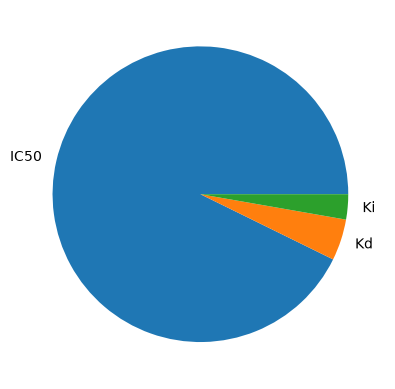

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

# Remove other standard types
# Note that Ki and Kd are cleaner measurements since they do not depend on ATP concentration. 
# BUT, IC50 is the dominant assay in the EGFR report card: https://www.ebi.ac.uk/chembl/explore/target/CHEMBL203
df = df[df["Standard Type"].isin(["IC50", "Ki", "Kd"])]
record(df, "Limit the type of measurements to IC50, Ki and Kd")

# Show the distribution
counts = df["Standard Type"].value_counts()
counts.plot(kind="pie")
plt.show()

But, almost all the affinity measurements are IC50 anyway, so it's better to stick with only IC50, due to systematic differences in measurements.

In [17]:
df = df[df["Standard Type"] == "IC50"]
record(df, comment="Assay Type, only IC50 for consistency of measure.")

18,123 rows | Assay Type, only IC50 for consistency of measure.


In [16]:
df["Assay Description"].unique()

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [32]:
terms = ["T790M", "L858R", "C797S", "G719", "A431", "L861Q", "E746", 
        r"\bexon", r"\bdel",  "insert", "mutant", "variant"]

for t in terms:
    mask = df["Assay Description"].str.contains(t, case=False, na=False, regex=True)
    print(t, mask.sum())
for t in terms:
    mask = df["Assay Description"].str.contains(t, case=False, na=False, regex=True)
    df = df[~mask]
record(df, comment="Remove mutants, deletions and other variants.")

T790M 4732
L858R 4773
C797S 1399
G719 1
A431 1072
L861Q 135
E746 98
\bexon 640
\bdel 2354
insert 97
mutant 4523
variant 0
9,422 rows | Remove mutants, deletions and other variants.


In [ ]:
# Check subset of remaining descriptions, looks good
# df["Assay Description"].unique()
# mask = df["Assay Description"].str.contains("mutant", case=False, na=False)
# df[mask]["Assay Description"].unique()

Flag the molecules with a covalent warhead: SMARTS of acrylamide (`C=CC(=O)N`), which target Cys797.

In [35]:
from rdkit import Chem

acrylamide = Chem.MolFromSmarts("C=CC(=O)N")

def has_acrylamide(smi, pattern=acrylamide):
    return None